In [1]:
# useful to autoreload the module without restarting the kernel
%load_ext autoreload
%autoreload 2

In [2]:
from mppi import Parsers as P, Optics as O
from mppi.Utilities import Constants as C, Utils as U
from mppi.Utilities import FourierTransform as FT
import matplotlib.pyplot as plt
import numpy as np
import os

# Analysis of the Optics modules

This notebook describes the various modules of the package built in order to extract both the linear and non-linear optical properties of a system
from the knowledge of the real-time polarization.

## Linear response analysis

We show how to compute the linear response starting from the real-time polarization.

To this aim we load the ndb produced by yambo_nl for LiF in the linear response regime using a delta-shaped pulse

In [3]:
file = 'Reference_data/nl_results/LiF-delta_pulse/ndb.Nonlinear'

In [4]:
data = P.YamboNLDBParser(file)

Parse file : Reference_data/nl_results/LiF-delta_pulse/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [5]:
time_fs = data.get_time() # in fs
time_au = data.IO_TIME_points
P_t = data.Polarization[0]
efield = data.Efield[0]
t_initial_au=efield["initial_time"]
t_initial_fs = t_initial_au/C.FsToAu

The module can deal with both time variables expressed in fs or in au.

The damp_ft function applies a damping in the time domain to produce a spread in the frequency domain and avoid 
spurious oscillations of the optical quantities.
The damping eta is expressed in eV

In [6]:
P_damped = U.damp_ft(P_t,time_fs,t_initial=t_initial_fs,eta=0.1,time_units='fs')

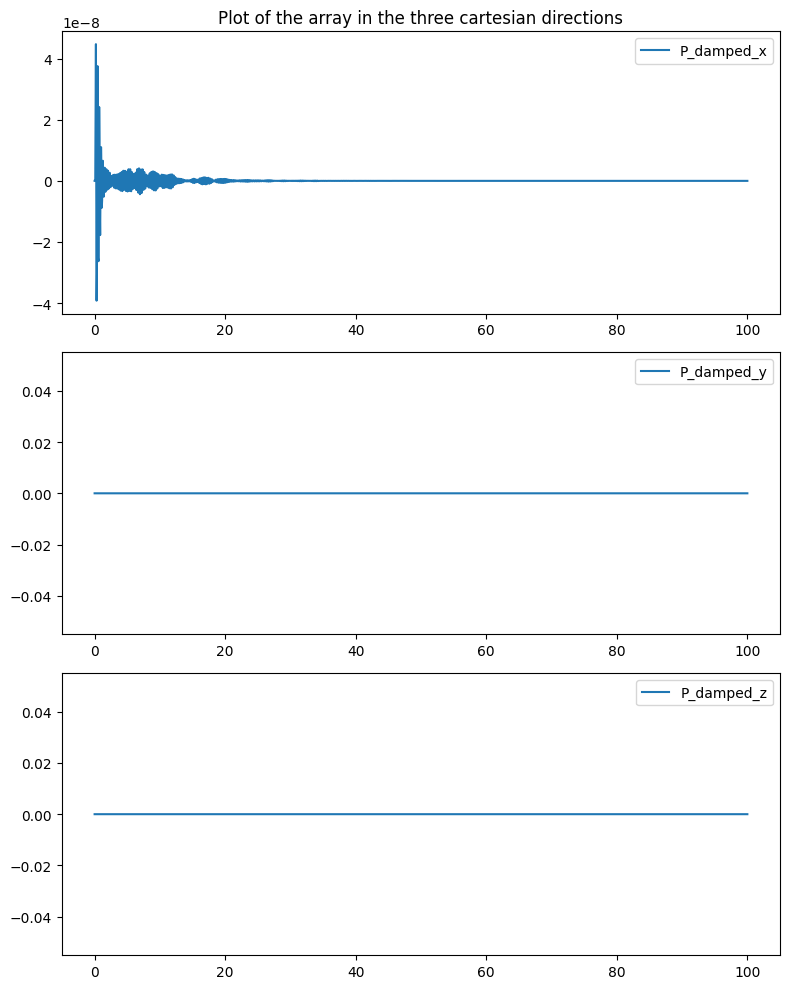

In [7]:
U.Plot_3dArray(time_fs,P_damped,label='P_damped')

The linear response is computed by the Linear_response function of the module

In [8]:
energy,chi = O.Linear_Response(time_fs,P_t,efield=efield,eta=0.1,time_units='fs')

Time units = fs. Rescaled to au


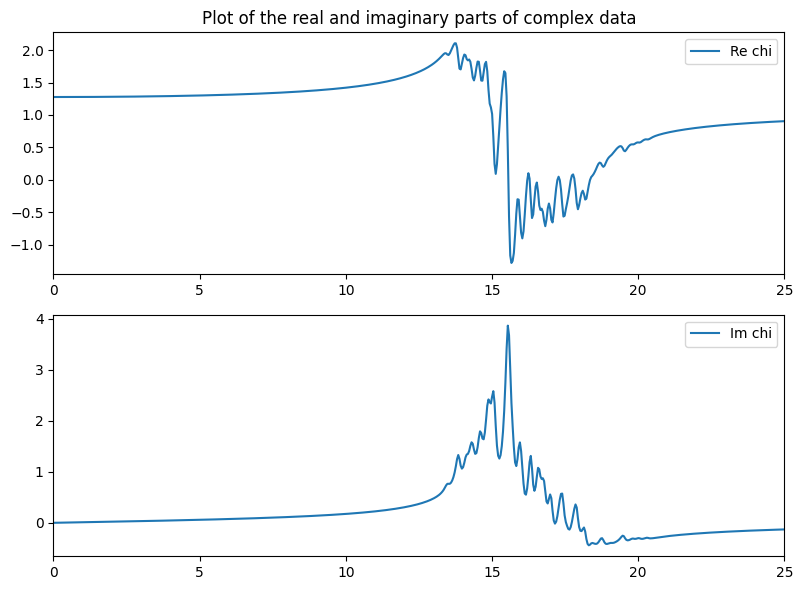

In [9]:
U.Plot_ComplexArray(energy,chi,xlim=(0,25),label='chi')

## Non-linear analysis for a sine-shaped pulse

We analyze the extraction of the non-linear response from a bunch of monocromatic sine-shaped fields

In [91]:
file = 'Reference_data/nl_results/LiF-sine_pulse-time_200fs-step_10as/ndb.Nonlinear'
data = P.YamboNLDBParser(file)

Parse file : Reference_data/nl_results/LiF-sine_pulse-time_200fs-step_10as/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [96]:
nl = O.Xn_single_frequency(data,Trange=[-1,-1],X_order=3,inactive_harmonics=None)

Time range of the simulation (in au): 0.0 - 8268.274667312273
Time range of the simulation (in fs): 0.0 - 200.00000162820604
Type of the external field: SIN
Order of the non-linear susceptibility extracted: 3
Number of frequencies: 50
Frequency range of the field (in Hartree): 0.18374663009599138 - 0.9040334200722775
Frequency range of the field (in eV): 5.000000477741239 - 24.600002350486893
Damping factor: 0.003674932601919828 Hartree 0.10000000955482478 eV
Dephasing time: 3265.3660079999995 au 78.98542721355673 fs


In [98]:
nl.perform_harmonic_analysis(0)

[({1: {'Omega': np.float64(0.18374663009599138),
    'A': np.float64(2.957721080963955e-06),
    'phi': np.float64(-0.8010439107700967)},
   2: {'Omega': np.float64(0.36749326019198275),
    'A': np.float64(5.419380239457008e-12),
    'phi': np.float64(-1.8322108504510013)},
   3: {'Omega': np.float64(0.5512398902879742),
    'A': np.float64(2.816933760314894e-12),
    'phi': np.float64(0.4173221020254258)}},
  np.float64(7.003216227650225e-13),
  np.float64(2.7920822417682045e-13)),
 ({1: {'Omega': np.float64(0.18374663009599138),
    'A': np.float64(0.0),
    'phi': np.float64(0.0)},
   2: {'Omega': np.float64(0.36749326019198275),
    'A': np.float64(0.0),
    'phi': np.float64(0.0)},
   3: {'Omega': np.float64(0.5512398902879742),
    'A': np.float64(0.0),
    'phi': np.float64(0.0)}},
  np.float64(0.0),
  np.float64(0.0)),
 ({1: {'Omega': np.float64(0.18374663009599138),
    'A': np.float64(0.0),
    'phi': np.float64(0.0)},
   2: {'Omega': np.float64(0.36749326019198275),
    'A'

In [88]:
from mppi.Optics.Xn_single_frequency import generate_frequencies
from mppi.Optics.Utils import fit_sum_frequencies, eval_sum_frequencies

In [89]:
Omegas = generate_frequencies(nl.fields_freqs[0],n_harmonics=3,inactive_harmonics=None)
Omegas

{1: np.float64(0.18374663009599138),
 2: np.float64(0.36749326019198275),
 3: np.float64(0.5512398902879742)}

In [90]:
fit_sum_frequencies(nl.time,nl.pol[0,0,:],Omegas)

({1: {'Omega': np.float64(0.18374663009599138),
   'A': np.float64(2.9570543919604696e-06),
   'phi': np.float64(-0.8007936311599596),
   'alpha': np.float64(2.058515487339826e-06),
   'beta': np.float64(-2.122895349609769e-06)},
  2: {'Omega': np.float64(0.36749326019198275),
   'A': np.float64(1.0714085163261478e-09),
   'phi': np.float64(1.4799186434907237),
   'alpha': np.float64(9.723315732494956e-11),
   'beta': np.float64(1.0669873110645782e-09)},
  3: {'Omega': np.float64(0.5512398902879742),
   'A': np.float64(2.175160283392667e-09),
   'phi': np.float64(1.6430273457644562),
   'alpha': np.float64(-1.5697746028334505e-10),
   'beta': np.float64(2.1694884962617012e-09)}},
 np.float64(4.91466004828978e-10),
 np.float64(5.857857085957795e-06))

In [12]:
iT = nl.set_time_sampling(0)
nl.time[iT[0]]/C.FsToAu,nl.time[iT[1]]/C.FsToAu

(np.float64(199.170001621449), np.float64(200.00000162820604))

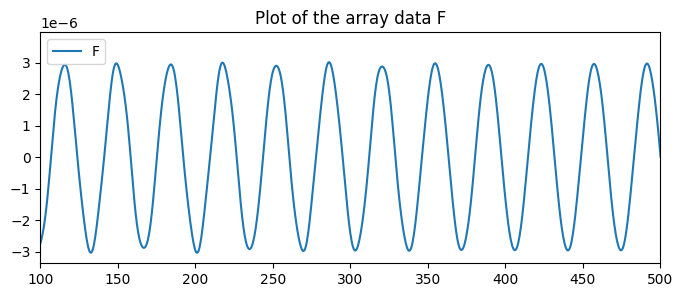

In [13]:
U.Plot_Array(nl.time,nl.pol[0,0,:],xlim=(100,500),figsize=(8,3))

In [25]:
A,phi,B0,res = nl.perform_harmonic_analysis(0)
A.shape

(3, 3)

In [26]:
A,phi,B0

(array([[2.95771971e-06, 0.00000000e+00, 0.00000000e+00],
        [5.76837017e-12, 0.00000000e+00, 0.00000000e+00],
        [4.93379403e-12, 0.00000000e+00, 0.00000000e+00]]),
 array([[-0.80409684,  0.        ,  0.        ],
        [-0.83708093,  0.        ,  0.        ],
        [ 0.84556894,  0.        ,  0.        ]]),
 array([5.79095679e-12, 0.00000000e+00, 0.00000000e+00]))

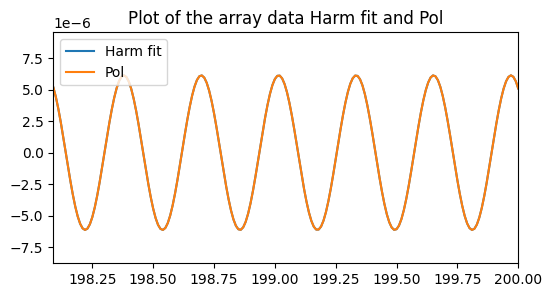

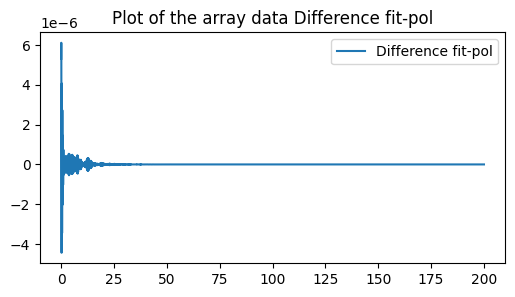

In [45]:
nl.check_harmonic_reliability(plot_ifreq=20)

In [56]:
chi = nl.compute_Xn(plot=False,set_units_of_measure=True)
chi.shape

(4, 50, 3)

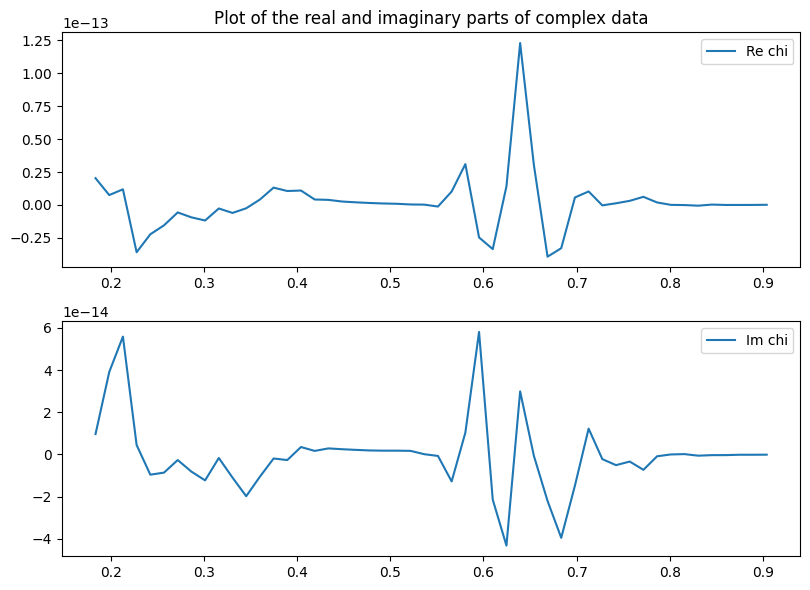

In [57]:
U.Plot_ComplexArray(nl.fields_freqs,chi[3,:,0],label='chi')

We compare this result with the one of the YamboPy module

In [35]:
from mppi.Optics import NLanalysisYamboPy as NLYP

In [36]:
SIG = NLYP.Xn_from_sine(data,X_order=3,solver='lstsq',nsamp=-1,debug_mode=False) #,T_range=[10*C.FsToAu,200*C.FsToAu]
#,T_range=[50.0*C.FsToAu,100.0*C.FsToAu]
print(SIG)


 * * *  Xn from signal class  * * * 

Max time: 8268.274667312273
Time step : 0.4134137333656136
Type Efield    : SIN
Number of runs   : 50
Max harmonic order   : 3
Solver           : lstsq
Frequency range: [0.18374663009599138,0.9040334200722775] [au] 



In [37]:
out = SIG.perform_analysis()
freqs,chi_yp = SIG.output_analysis(out)

100%|████████████████████████████████████████████████████| 50/50 [00:00<00:00, 1210.37it/s]

# Field details:# Type field            SIN
# Field intensity       1.553659979614254e-07
# Field versor          [1. 0. 0.]
# Analysis details:# Max harmonic order   : 3
# Solver               : lstsq
# Sampling points      : 7
# Start sampling time  : 199.17286816862352 [fs] 

# Field details:# Type field            SIN
# Field intensity       1.553659979614254e-07
# Field versor          [1. 0. 0.]
# Analysis details:# Max harmonic order   : 3
# Solver               : lstsq
# Sampling points      : 7
# Start sampling time  : 199.17286816862352 [fs] 

# Field details:# Type field            SIN
# Field intensity       1.553659979614254e-07
# Field versor          [1. 0. 0.]
# Analysis details:# Max harmonic order   : 3
# Solver               : lstsq
# Sampling points      : 7
# Start sampling time  : 199.17286816862352 [fs] 

# Field details:# Type field            SIN
# Field intensity       1.553659979614254e-07
# Field versor          [1. 0. 0.]
# Analysis details:# Max harmonic o

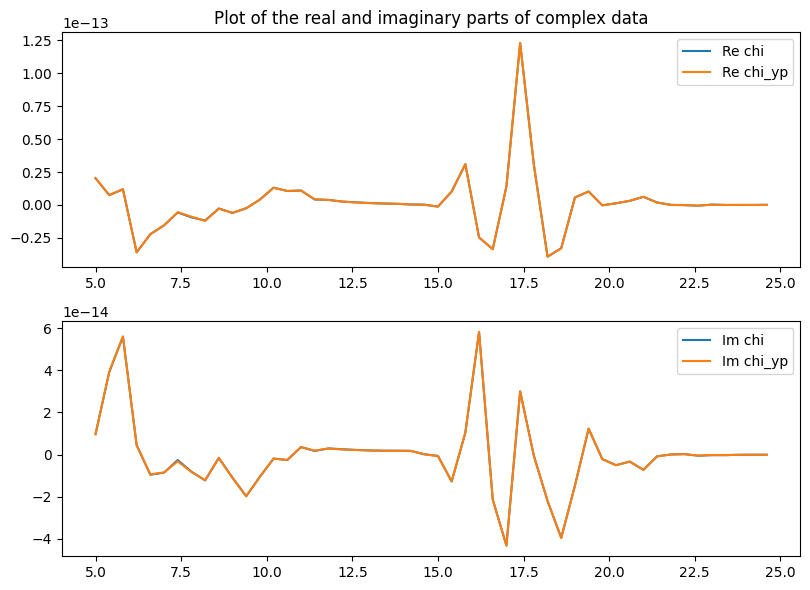

In [61]:
harm = 3
U.Plot_ComplexArray(nl.fields_freqs*C.HaToeV,chi[harm,:,0],label='chi',data2=chi_yp[harm,:,0],label2='chi_yp')

## Non-linear analysis for frequency mixing

We analyze the extraction of the non-linear response from a bunch of monocromatic sine-shaped fields

In [76]:
file = 'Reference_data/nl_results/LiF-pump_1.55-nlenrange_5.0-25.0-nlensteps_80-bands_3-6-damp_0.2-sin/ndb.Nonlinear'
data = P.YamboNLDBParser(file)

Parse file : Reference_data/nl_results/LiF-pump_1.55-nlenrange_5.0-25.0-nlensteps_80-bands_3-6-damp_0.2-sin/ndb.Nonlinear
Field 3 not found


In [77]:
nl = O.Xn_frequency_mixing(data,Trange=[-1,-1],X_order=3,inactive_harmonics=None)

Time range of the simulation (in au): 0.0 - 6201.206000484204
Time range of the simulation (in fs): 0.0 - 150.00000122115452
Type of the probe field: SIN
Type of the pump field: SIN
Order of the non-linear susceptibility extracted: 3
Number of frequencies: 80
Frequency range of the probe (in Hartree): 0.18374663009599138 - 0.9095458189751573
Frequency range of the probe (in eV): 5.000000477741239 - 24.75000236481913
Frequency of the pump : 0.05696145532975733  Hartree - 1.550000148099784  eV
Damping factor: 0.003674932601919828 Hartree 0.10000000955482478 eV
Dephasing time: 3265.3660079999995 au 78.98542721355673 fs


In [79]:
from mppi.Optics.Xn_frequency_mixing import generate_frequencies
from mppi.Optics.Utils import fit_sum_frequencies, eval_sum_frequencies

In [82]:
Omegas = generate_frequencies(nl.probe_freqs[0],nl.pump_freq)
Omegas

{(1, 0): np.float64(0.18374663009599138),
 (0, 1): np.float64(0.05696145532975733),
 (0, 2): np.float64(0.11392291065951465),
 (0, 3): np.float64(0.17088436598927198),
 (1, 1): np.float64(0.2407080854257487),
 (1, -1): np.float64(0.12678517476623405),
 (1, 2): np.float64(0.297669540755506),
 (1, -2): np.float64(0.06982371943647672),
 (1, 3): np.float64(0.3546309960852634),
 (1, -3): np.float64(0.012862264106719395)}

In [84]:
fit_sum_frequencies(nl.time,nl.pol[0,0,:],Omegas)

({(1, 0): {'Omega': np.float64(0.18374663009599138),
   'A': np.float64(9.322288248663264e-08),
   'phi': np.float64(-0.7975029035789221),
   'alpha': np.float64(6.511579585768146e-08),
   'beta': np.float64(-6.671161030088597e-08)},
  (0, 1): {'Omega': np.float64(0.05696145532975733),
   'A': np.float64(2.743793411789482e-06),
   'phi': np.float64(-0.24808312616611405),
   'alpha': np.float64(2.6597918568580914e-06),
   'beta': np.float64(-6.73728108936202e-07)},
  (0, 2): {'Omega': np.float64(0.11392291065951465),
   'A': np.float64(4.4799066832796845e-10),
   'phi': np.float64(1.5213152371877776),
   'alpha': np.float64(2.2158021949509984e-11),
   'beta': np.float64(4.4744235491538444e-10)},
  (0, 3): {'Omega': np.float64(0.17088436598927198),
   'A': np.float64(4.535761708994841e-10),
   'phi': np.float64(1.5057564673527268),
   'alpha': np.float64(2.9479736025054293e-11),
   'beta': np.float64(4.526171538637606e-10)},
  (1, 1): {'Omega': np.float64(0.2407080854257487),
   'A': np.

In [20]:
nl.pol.shape

(80, 3, 15001)

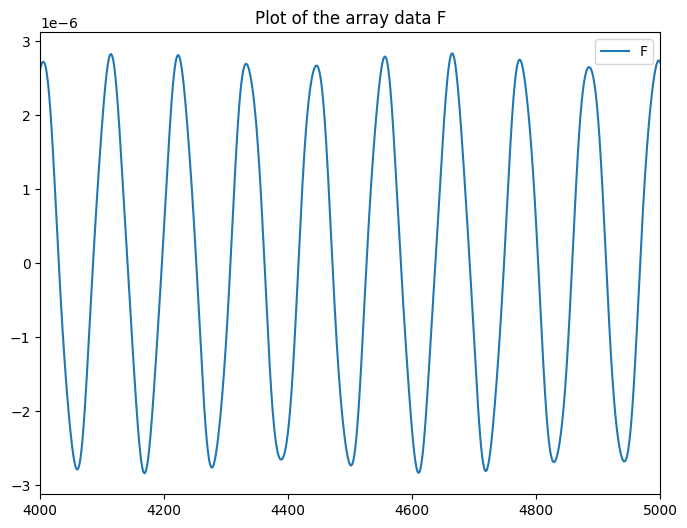

In [25]:
U.Plot_Array(nl.time,nl.pol[0,0],xlim=(4000,5000))